In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import load_iris, make_blobs, make_circles, make_moons
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# 设置中文字体为宋体或黑体
plt.rcParams["font.sans-serif"] = ["SimSong", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
X_blobs, y_true = make_blobs(
    n_samples=300, n_features=2, centers=4, cluster_std=1.0, random_state=42
)
X_blobs = pd.DataFrame(X_blobs, columns=["feature_1", "feature_2"])
print(f"数据形状: {X_blobs.shape}")

数据形状: (300, 2)


簇中心坐标:
[[-2.70981136  8.97143336]
 [-6.83235205 -6.83045748]
 [ 4.7182049   2.04179676]
 [-8.87357218  7.17458342]]


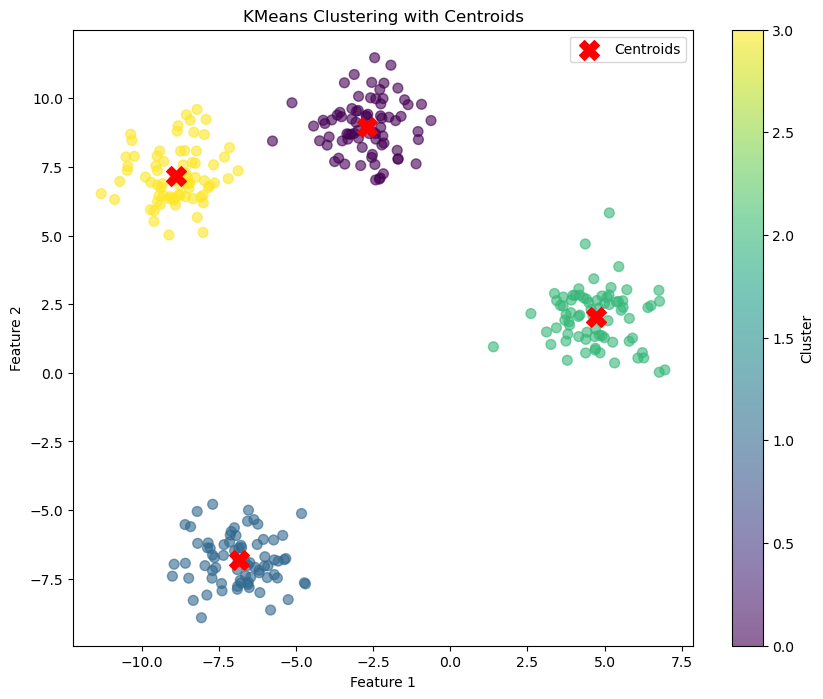

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_blobs)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
print(f"簇中心坐标:\n{centroids}")
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_blobs.iloc[:, 0], X_blobs.iloc[:, 1], c=labels, cmap="viridis", alpha=0.6, s=50
)
ax.scatter(
    centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200, label="Centroids"
)
ax.set(title="KMeans Clustering with Centroids", xlabel="Feature 1", ylabel="Feature 2")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Cluster")

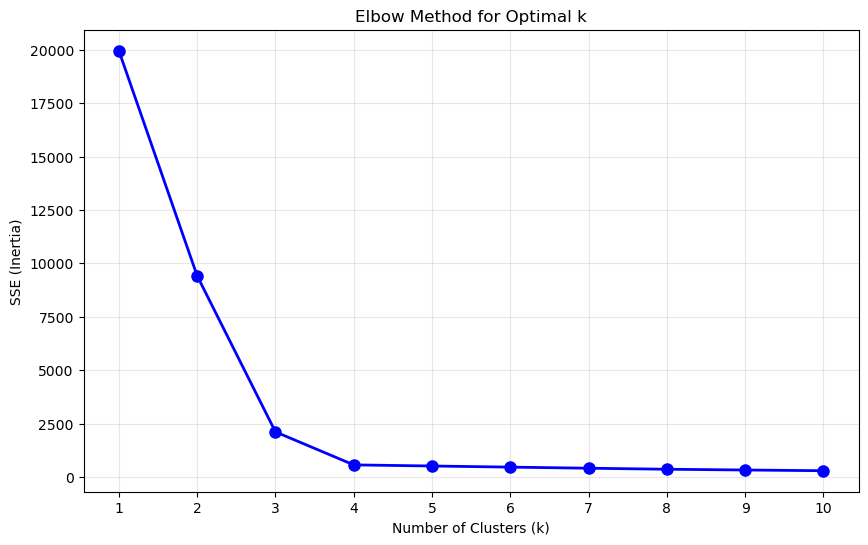

In [4]:
k_range = range(1, 11)
sse = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_blobs)
    sse.append(kmeans.inertia_)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, sse, "bo-", linewidth=2, markersize=8)
ax.set(
    xlabel="Number of Clusters (k)",
    ylabel="SSE (Inertia)",
    title="Elbow Method for Optimal k",
    xticks=list(k_range),
)
ax.grid(True, alpha=0.3)


最佳k值: 4, 轮廓系数: 0.7916


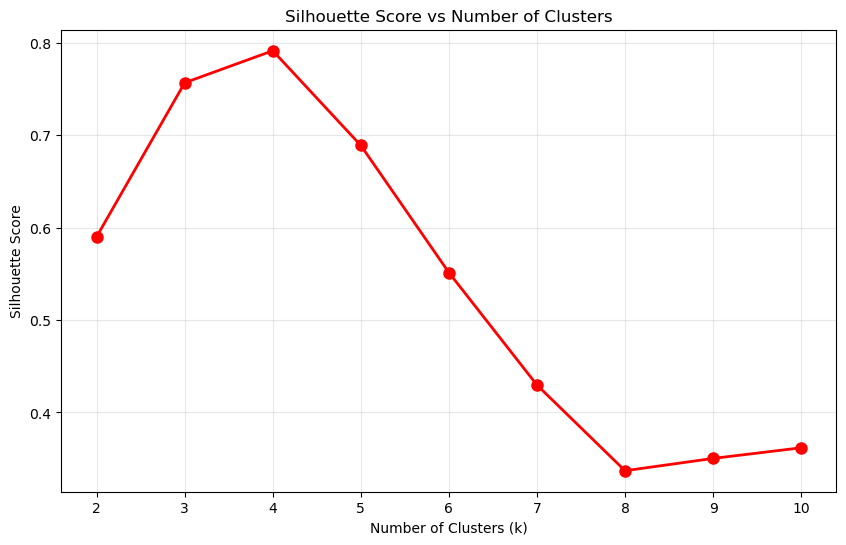

In [5]:
k_range = range(2, 11)
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_blobs)
    silhouette_scores.append(silhouette_score(X_blobs, labels))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, silhouette_scores, "ro-", linewidth=2, markersize=8)
ax.set(
    xlabel="Number of Clusters (k)",
    ylabel="Silhouette Score",
    title="Silhouette Score vs Number of Clusters",
    xticks=list(k_range),
)
ax.grid(True, alpha=0.3)
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"最佳k值: {best_k}, 轮廓系数: {max(silhouette_scores):.4f}")

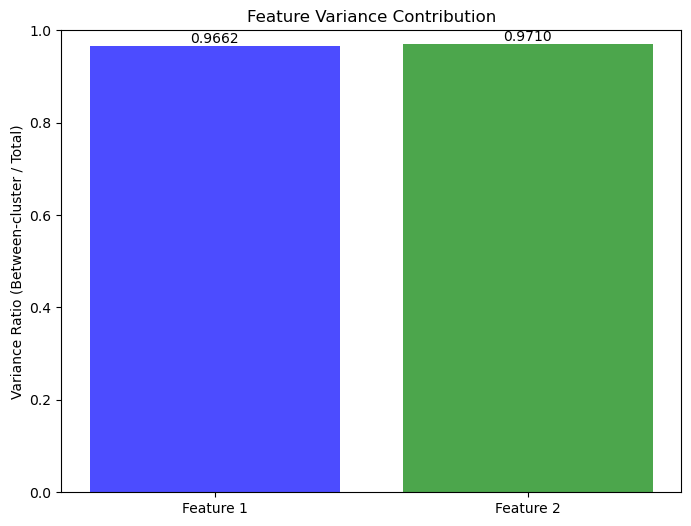

In [6]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_blobs)
total_variance = X_blobs.var(axis=0)
between_cluster_variance = []
for i in range(X_blobs.shape[1]):
    feature_values = X_blobs.iloc[:, i]
    cluster_means = [feature_values[labels == j].mean() for j in range(best_k)]
    between_cluster_variance.append(np.var(cluster_means))
variance_ratio = np.array(between_cluster_variance) / total_variance
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    ["Feature 1", "Feature 2"], variance_ratio, color=["blue", "green"], alpha=0.7
)
ax.set(
    ylabel="Variance Ratio (Between-cluster / Total)",
    title="Feature Variance Contribution",
    ylim=(0, 1),
)
for bar, ratio in zip(bars, variance_ratio):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        f"{ratio:.4f}",
        ha="center",
        va="bottom",
    )


random: 均值=1162.4593, 标准差=731.8403
k-means++: 均值=564.9142, 标准差=0.0000


[Text(0, 0.5, 'SSE (Inertia)'),
 Text(0.5, 1.0, 'KMeans Initialization Methods Comparison')]

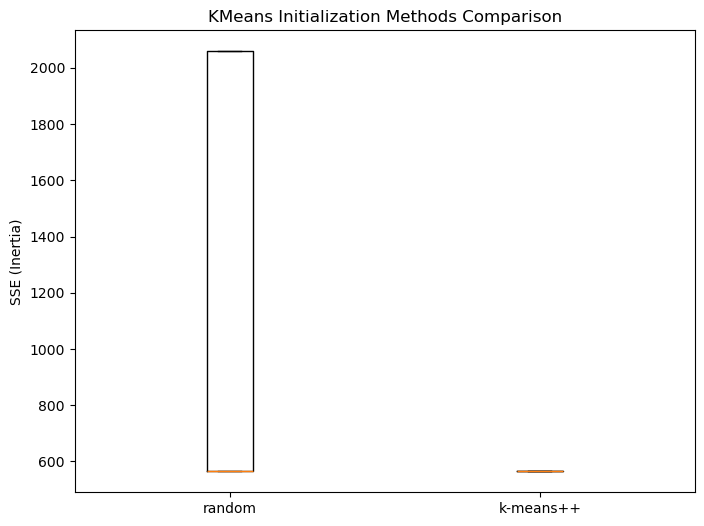

In [7]:
init_methods = ["random", "k-means++"]
n_runs = 10
results = {"random": [], "k-means++": []}
for init in init_methods:
    for _ in range(n_runs):
        kmeans = KMeans(n_clusters=4, init=init, n_init=1, random_state=None)
        kmeans.fit(X_blobs)
        results[init].append(kmeans.inertia_)
for init in init_methods:
    mean_sse = np.mean(results[init])
    std_sse = np.std(results[init])
    print(f"{init}: 均值={mean_sse:.4f}, 标准差={std_sse:.4f}")
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [results["random"], results["k-means++"]], tick_labels=["random", "k-means++"]
)
ax.set(ylabel="SSE (Inertia)", title="KMeans Initialization Methods Comparison")

Text(0.5, 0.98, 'KMeans Clustering on Different Shaped Datasets')

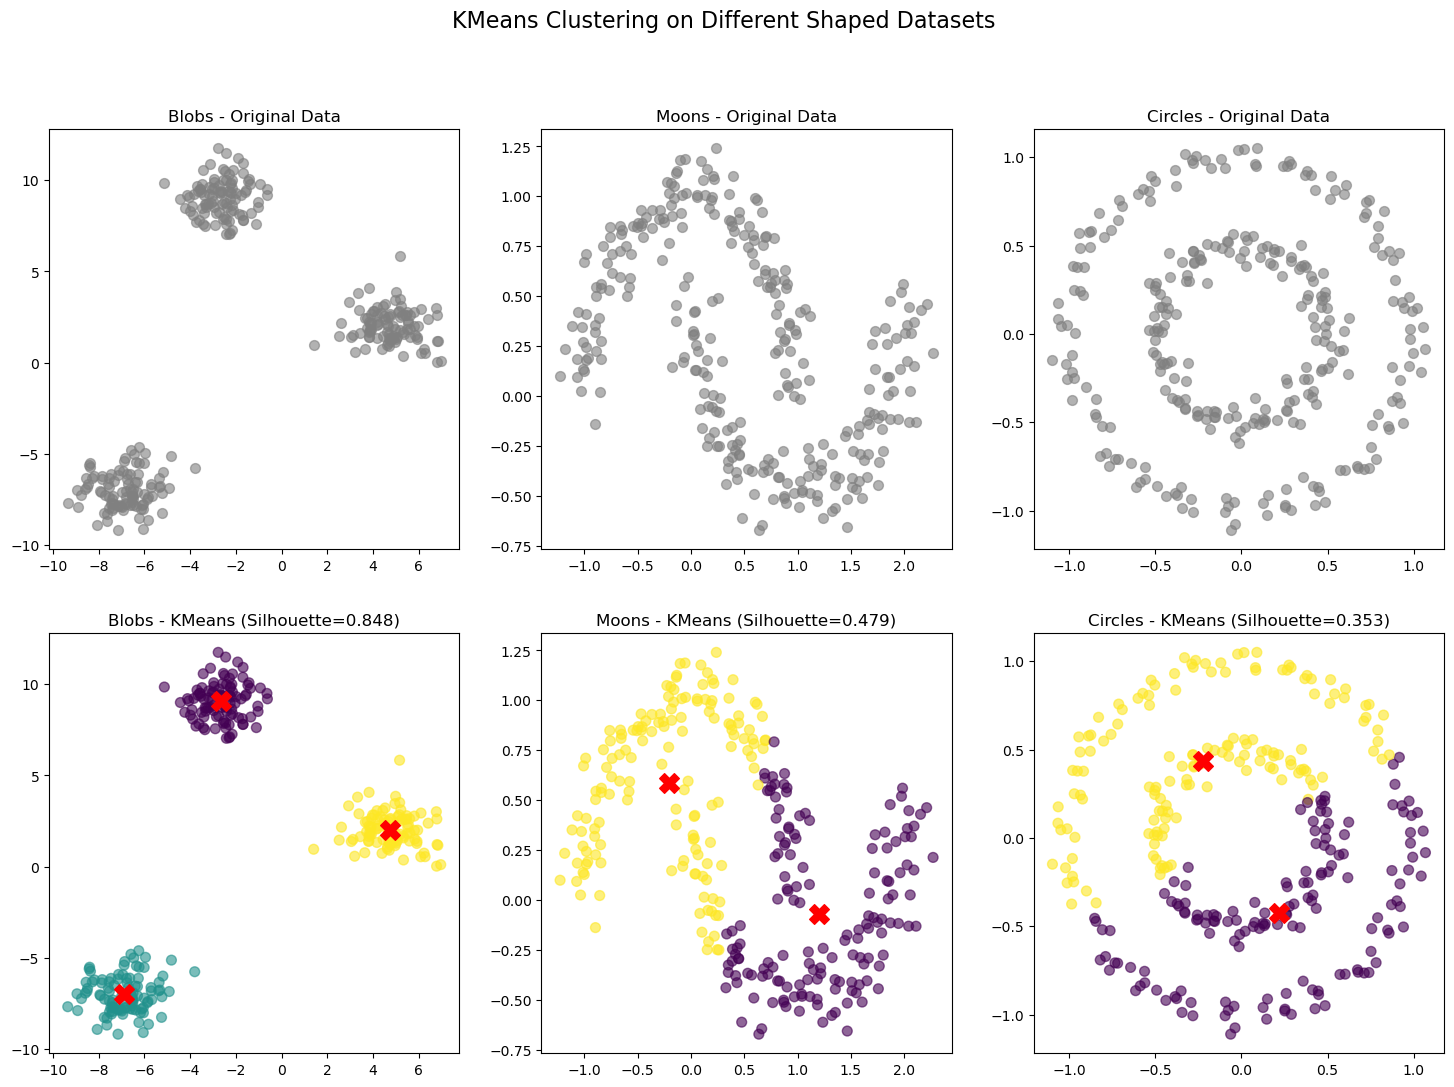

In [8]:
X_blobs_shape, _ = make_blobs(n_samples=300, centers=3, random_state=42)
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
X_circles, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
datasets = [
    ("Blobs", X_blobs_shape, 3),
    ("Moons", X_moons, 2),
    ("Circles", X_circles, 2),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for idx, (name, X, n_clusters) in enumerate(datasets):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette = silhouette_score(X, labels)
    axes[0, idx].scatter(X[:, 0], X[:, 1], c="gray", alpha=0.6, s=50)
    axes[0, idx].set(title=f"{name} - Original Data")
    scatter = axes[1, idx].scatter(
        X[:, 0], X[:, 1], c=labels, cmap="viridis", alpha=0.6, s=50
    )
    axes[1, idx].scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        c="red",
        marker="X",
        s=200,
    )
    axes[1, idx].set(title=f"{name} - KMeans (Silhouette={silhouette:.3f})")
plt.suptitle("KMeans Clustering on Different Shaped Datasets", fontsize=16)


eps=0.3: 簇数=11, 噪声点数=210
eps=0.5: 簇数=5, 噪声点数=85
eps=0.7: 簇数=4, 噪声点数=32


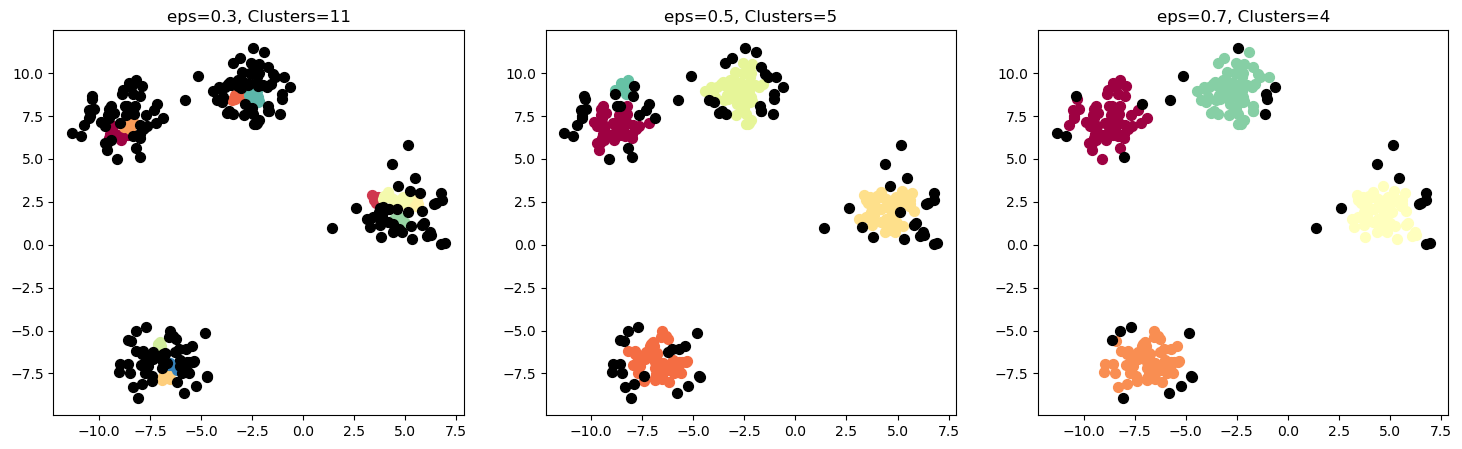

In [9]:
eps_values = [0.3, 0.5, 0.7]
n_clusters_list = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_blobs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    n_clusters_list.append(n_clusters)
    print(f"eps={eps}: 簇数={n_clusters}, 噪声点数={n_noise}")
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]
        class_mask = labels == k
        xy = X_blobs[class_mask]
        axes[idx].scatter(
            xy.iloc[:, 0],
            xy.iloc[:, 1],
            c=[col],
            s=50,
            label=f"Cluster {k}" if k != -1 else "Noise",
        )
    axes[idx].set(title=f"eps={eps}, Clusters={n_clusters}")


min_samples=5: 簇数=5, 噪声点数=85
min_samples=10: 簇数=4, 噪声点数=187


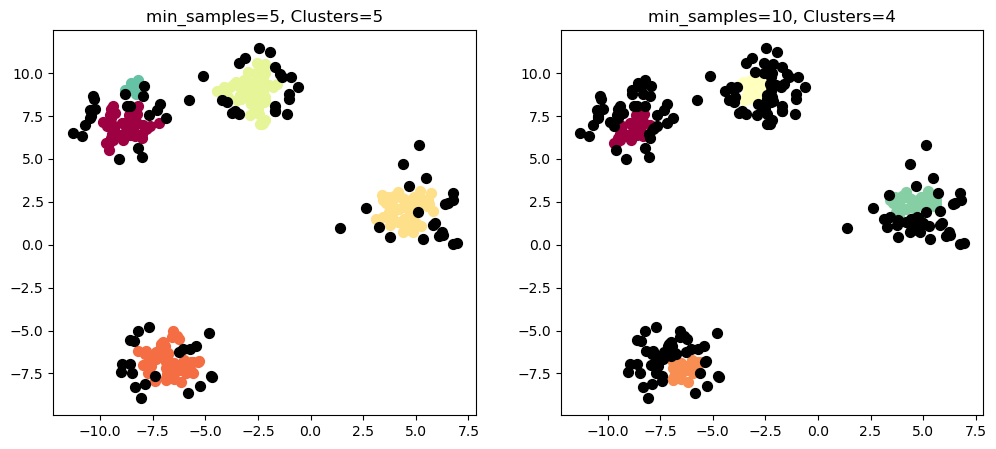

In [ ]:
min_samples_values = [5, 10]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, min_samples in enumerate(min_samples_values):
    dbscan = DBSCAN(eps=0.5, min_samples=min_samples)
    labels = dbscan.fit_predict(X_blobs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"min_samples={min_samples}: 簇数={n_clusters}, 噪声点数={n_noise}")
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]
        class_mask = labels == k
        xy = X_blobs[class_mask]
        axes[idx].scatter(xy.iloc[:, 0], xy.iloc[:, 1], c=[col], s=50)
    axes[idx].set(title=f"min_samples={min_samples}, Clusters={n_clusters}")

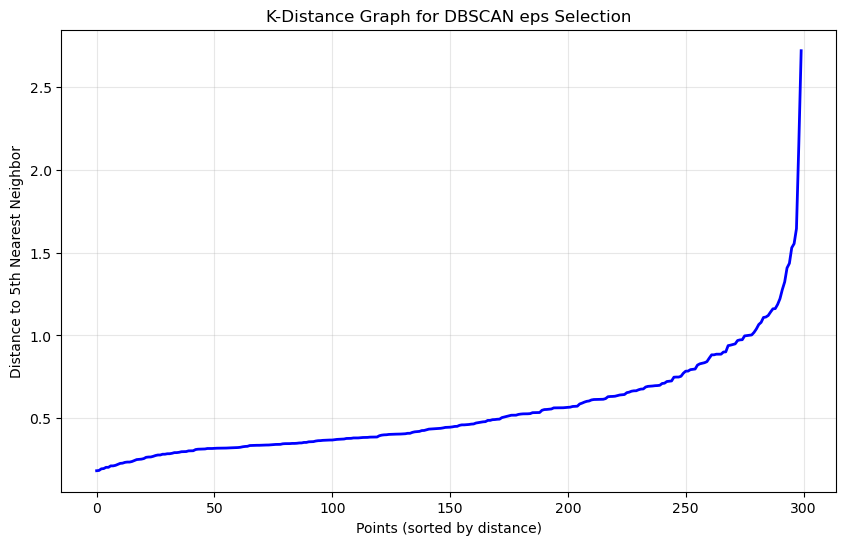

In [11]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_blobs)
distances, indices = neighbors.kneighbors(X_blobs)
k_distances = distances[:, 4]
k_distances_sorted = np.sort(k_distances)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(k_distances_sorted)), k_distances_sorted, "b-", linewidth=2)
ax.set(
    xlabel="Points (sorted by distance)",
    ylabel="Distance to 5th Nearest Neighbor",
    title="K-Distance Graph for DBSCAN eps Selection",
)
ax.grid(True, alpha=0.3)


Iris - KMeans: 0.4799, DBSCAN: 0.3565
Moons - KMeans: 0.4910, DBSCAN: 0.2503


[Text(0.5, 1.0, 'Moons - DBSCAN (Silhouette=0.250)')]

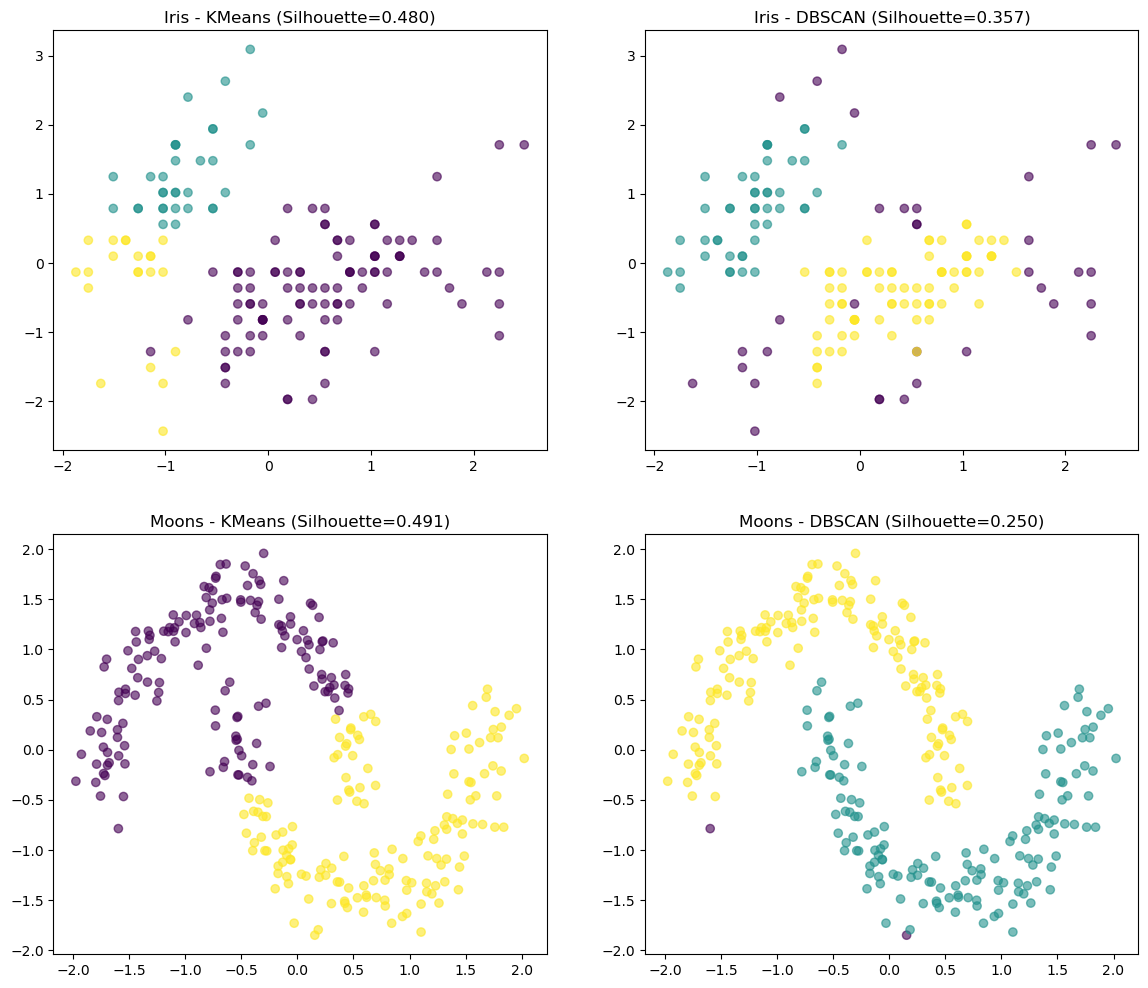

In [12]:
iris = load_iris()
X_iris = iris.data
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)
X_moons_scaled = scaler.fit_transform(X_moons)
kmeans_iris = KMeans(n_clusters=3, random_state=42).fit(X_iris_scaled)
dbscan_iris = DBSCAN(eps=0.5, min_samples=5).fit(X_iris_scaled)
sil_kmeans_iris = silhouette_score(X_iris_scaled, kmeans_iris.labels_)
sil_dbscan_iris = (
    silhouette_score(X_iris_scaled, dbscan_iris.labels_)
    if len(set(dbscan_iris.labels_)) > 1
    else -1
)
kmeans_moons = KMeans(n_clusters=2, random_state=42).fit(X_moons_scaled)
dbscan_moons = DBSCAN(eps=0.3, min_samples=5).fit(X_moons_scaled)
sil_kmeans_moons = silhouette_score(X_moons_scaled, kmeans_moons.labels_)
sil_dbscan_moons = (
    silhouette_score(X_moons_scaled, dbscan_moons.labels_)
    if len(set(dbscan_moons.labels_)) > 1
    else -1
)
print(f"Iris - KMeans: {sil_kmeans_iris:.4f}, DBSCAN: {sil_dbscan_iris:.4f}")
print(f"Moons - KMeans: {sil_kmeans_moons:.4f}, DBSCAN: {sil_dbscan_moons:.4f}")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes[0, 0].scatter(
    X_iris_scaled[:, 0],
    X_iris_scaled[:, 1],
    c=kmeans_iris.labels_,
    cmap="viridis",
    alpha=0.6,
)
axes[0, 0].set(title=f"Iris - KMeans (Silhouette={sil_kmeans_iris:.3f})")
axes[0, 1].scatter(
    X_iris_scaled[:, 0],
    X_iris_scaled[:, 1],
    c=dbscan_iris.labels_,
    cmap="viridis",
    alpha=0.6,
)
axes[0, 1].set(title=f"Iris - DBSCAN (Silhouette={sil_dbscan_iris:.3f})")
axes[1, 0].scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=kmeans_moons.labels_,
    cmap="viridis",
    alpha=0.6,
)
axes[1, 0].set(title=f"Moons - KMeans (Silhouette={sil_kmeans_moons:.3f})")
axes[1, 1].scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=dbscan_moons.labels_,
    cmap="viridis",
    alpha=0.6,
)
axes[1, 1].set(title=f"Moons - DBSCAN (Silhouette={sil_dbscan_moons:.3f})")
